In [ ]:
# pip install langchain langgraph langsmith langchain_groq langchain_community


   ---------------------------------------- 0/2 [groq]
   ---------------------------------------- 0/2 [groq]
   ---------------------------------------- 0/2 [groq]
   ---------------------------------------- 0/2 [groq]
   ---------------------------------------- 0/2 [groq]
   ---------------------------------------- 0/2 [groq]
   ---------------------------------------- 0/2 [groq]
   ---------------------------------------- 0/2 [groq]
   ---------------------------------------- 0/2 [groq]
   ---------------------------------------- 0/2 [groq]
   ---------------------------------------- 0/2 [groq]
   ---------------------------------------- 0/2 [groq]
   ---------------------------------------- 0/2 [groq]
   ---------------------------------------- 0/2 [groq]
   ---------------------------------------- 0/2 [groq]
   ---------------------------------------- 0/2 [groq]
   ---------------------------------------- 0/2 [groq]
   ---------------------------------------- 0/2 [groq]
   ------


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
groq_api_key = "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"

In [5]:
from langchain_groq import ChatGroq

In [6]:
llm = ChatGroq(groq_api_key = groq_api_key, model_name = "llama-3.3-70b-versatile")

In [7]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph,START,END 

In [8]:
class State(TypedDict):
    messages:Annotated[list,add_messages] 
    
graph_builder=StateGraph(State)

In [9]:
graph_builder

In [10]:
def chatbot(state:State):
    return{"messages":llm.invoke(state['messages'])}

In [11]:
graph_builder.add_node('chatbot',chatbot)

In [12]:
graph_builder

In [13]:
graph_builder.add_edge(START, 'chatbot')
graph_builder.add_edge('chatbot', END)

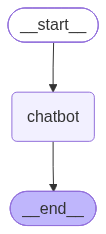

In [14]:
graph_builder.compile()

In [15]:
graph = graph_builder.compile()

In [ ]:
while True:
    user_input=input("user:")
    if user_input.lower() in ['quit','q']:
        print('Good Bye, thank you using LangGrpah Framework create by Ravi Teja')
        break 
    for event in graph.stream({'messages':('user', user_input)}):
        print(event.values())
        for value in event.values():
            print(value['messages'])
            print('Assistant:',value['messages'].content)

dict_values([{'messages': AIMessage(content='**Artificial Intelligence (AI)** refers to the development of computer systems that can perform tasks that would typically require human intelligence, such as:\n\n1. **Learning**: AI systems can learn from data and improve their performance over time.\n2. **Problem-solving**: AI systems can analyze problems and find solutions.\n3. **Reasoning**: AI systems can draw inferences and make decisions based on available data.\n4. **Perception**: AI systems can interpret and understand data from sensors, such as images, speech, and text.\n\nThe goal of AI is to create systems that can think and act like humans, but with the ability to process vast amounts of data quickly and accurately.\n\n**Types of AI:**\n\n1. **Narrow or Weak AI**: Designed to perform a specific task, such as facial recognition or language translation.\n2. **General or Strong AI**: A hypothetical AI system that possesses human-like intelligence and can perform any intellectual ta